In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from minilearn.decomposition import PCA as MiniPCA
from minilearn.classifiers import LogisticRegression as MiniLR

from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

# load saved train and test data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv("../data/test_features.csv")

features_cols = [col for col in train_df.columns if col != 'emotion']

X_train = train_df[features_cols].values
y_train = train_df['emotion'].values

X_test = test_df[features_cols].values
y_test = test_df['emotion'].values

#fix the fearful label mistake
y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")


Training set: (1961, 112)
Test set: (491, 112)
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


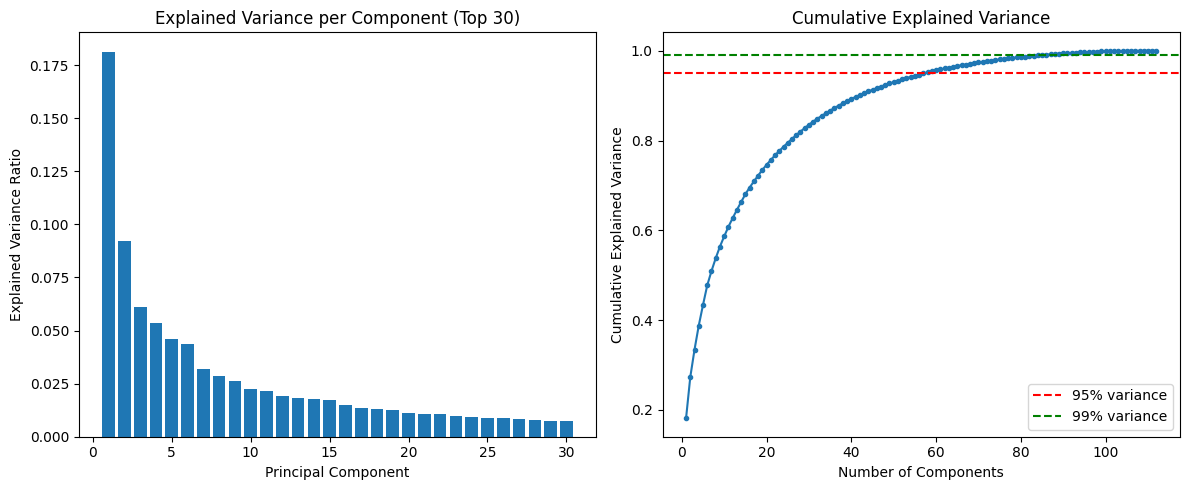

Components needed for 95% variance: 58
Components needed for 99% variance: 85


In [2]:
#fit Minilearn PCA on training data
mini_pca = MiniPCA(n_components=112)
mini_pca.fit(X_train)

cumulative_variance = np.cumsum(mini_pca.explained_variance_ratio_)

plt.figure(figsize=(12,5))
#individual variance
plt.subplot(1,2,1)
plt.bar(range(1,31), mini_pca.explained_variance_ratio_[:30])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance per Component (Top 30)")

# cumulative variance
plt.subplot(1,2,2)
plt.plot(range(1,113), cumulative_variance, marker='.')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()

plt.tight_layout()
plt.show()

n_95 = np.argmax(cumulative_variance >= 0.95) +1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")


In [3]:
#comparing MiniLeanr Vs Sklearn
mini_pca_50 = MiniPCA(n_components=50)
X_train_mini_pca = mini_pca_50.fit_transform(X_train)
X_test_mini_pca = mini_pca_50.transform(X_test)

#SKlearn
sklearn_pca_50 = SklearnPCA(n_components=50, random_state=42)
X_train_sklearn_pca = sklearn_pca_50.fit_transform(X_train)
X_test_sklearn_pca = sklearn_pca_50.transform(X_test)

#testing
svm = SVC(kernel='rbf', C=10, gamma="scale")

svm.fit(X_train_mini_pca, y_train)
mini_pca_acc = accuracy_score(y_test, svm.predict(X_test_sklearn_pca))
svm.fit(X_train_sklearn_pca, y_train)
sklearn_pca_acc = accuracy_score(y_test, svm.predict(X_test_sklearn_pca))

print(f"MiniLearn PCA (50 components) + Svm: {mini_pca_acc:.4f}")
print(f"Sklearn PCA (50 Components) + SVM: {sklearn_pca_acc:.4f}")



MiniLearn PCA (50 components) + Svm: 0.6843
Sklearn PCA (50 Components) + SVM: 0.6843


In [4]:
# transform data with different numbers of componets
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_components_list = [10, 20, 30, 40, 50, 58, 85, 112]
svm_scores = []
lr_scores = []
rf_scores = []

for n in n_components_list:
    print(f"testing {n} components")

    #apply sklearn PCA
    pca = SklearnPCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    #SVM
    svm = SVC(kernel='rbf', C=10, gamma='scale')
    svm_score = np.mean(cross_val_score(svm, X_train_pca, y_train, cv=skf))
    svm_scores.append(svm_score)

    #logistic Regression
    lr = SklearnLR(max_iter=1000)
    lr_score = np.mean(cross_val_score(lr, X_train_pca, y_train, cv=skf))
    lr_scores.append(lr_score)

    #random forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_score = np.mean(cross_val_score(rf, X_train_pca, y_train, cv=skf))
    rf_scores.append(rf_score)


testing 10 components
testing 20 components
testing 30 components
testing 40 components
testing 50 components
testing 58 components
testing 85 components
testing 112 components


Compoments      SVM        LR         RF        
10              0.4253     0.3620     0.4166    
20              0.5288     0.4355     0.4727    
30              0.6048     0.4814     0.5003    
40              0.6354     0.5140     0.5038    
50              0.6558     0.5344     0.5232    
58              0.6843     0.5655     0.5242    
85              0.7017     0.6114     0.5314    
112             0.7170     0.6196     0.5222    


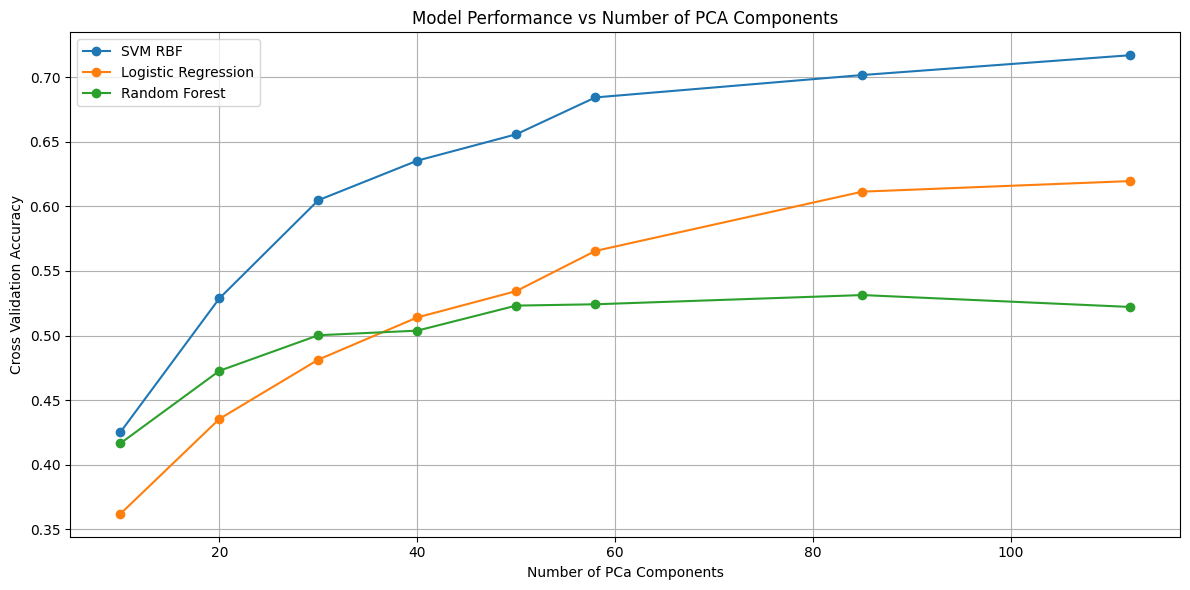

In [5]:
#Print scores table
print(f"{'Compoments':<15} {'SVM':<10} {'LR':<10} {'RF':<10}")

for i,n in enumerate(n_components_list):
    print(f"{n:<15} {svm_scores[i]:<10.4f} {lr_scores[i]:<10.4f} { rf_scores[i]:<10.4f}")

#PLots
plt.figure(figsize=(12,6))
plt.plot(n_components_list, svm_scores, marker='o', label='SVM RBF')
plt.plot(n_components_list, lr_scores, marker='o', label='Logistic Regression')
plt.plot(n_components_list, rf_scores, marker='o', label='Random Forest')
plt.xlabel('Number of PCa Components')
plt.ylabel('Cross Validation Accuracy')
plt.title('Model Performance vs Number of PCA Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
mini_pca_50 = MiniPCA(n_components=50)
mini_pca_50.fit(X_train)
sklearn_pca_50 = SklearnPCA(n_components=50, random_state=42)
sklearn_pca_50.fit(X_train)

print("Mini Learn Variance first 5")
print(mini_pca_50.explained_variance_ratio_[:5])

print("\nSKelarn Explained variance first 5")

print(sklearn_pca_50.explained_variance_ratio_[:5])

#comapre transform data shape

X_mini = mini_pca_50.transform(X_train)
X_sklearn = sklearn_pca_50.transform(X_train)

print(f"Mini learn transform shape: {X_mini.shape}")
print(f"Sklearn transformed shape: {X_sklearn.shape}")

print(f"\n MiniLearn first 5 samples {X_mini[0,:5]}")
print(f"skelarn first 5 sample: {X_sklearn[0,:5]}")


Mini Learn Variance first 5
[0.18139251 0.09196263 0.06105049 0.05362522 0.04588905]

SKelarn Explained variance first 5
[0.18139251 0.09196263 0.06105049 0.05362522 0.04588905]
Mini learn transform shape: (1961, 50)
Sklearn transformed shape: (1961, 50)

 MiniLearn first 5 samples [-0.44264143 -0.6963453   6.57722965  0.94350727 -1.12065193]
skelarn first 5 sample: [-0.44264143 -0.6963453   6.57722965  0.94350727 -1.12065193]


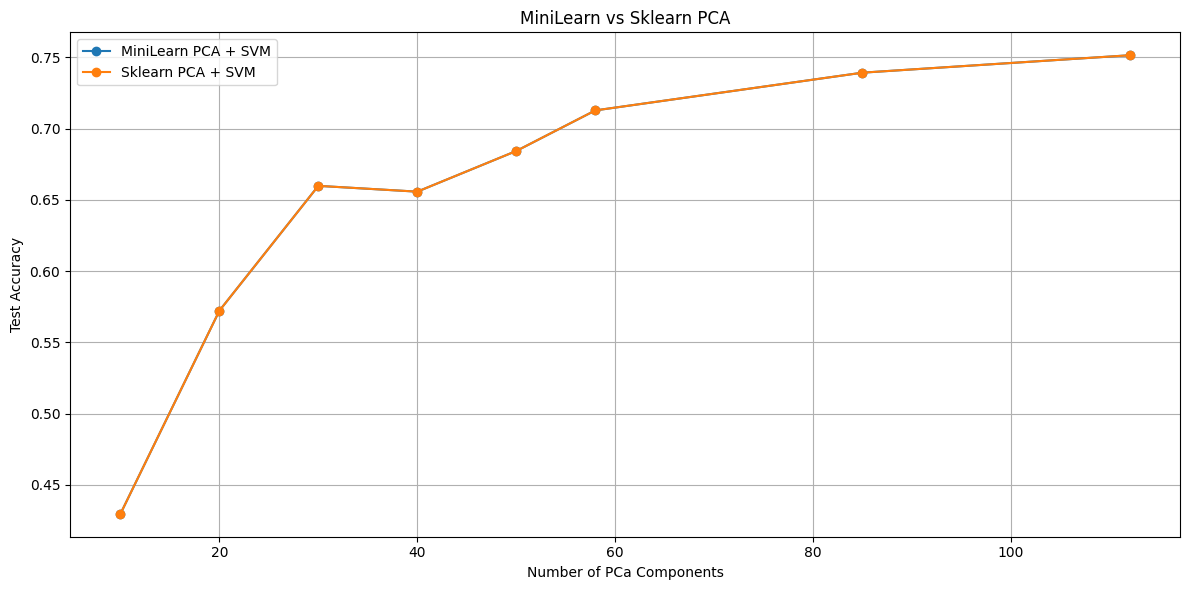

In [7]:
# Comparing my Minilearn to SKlearn
mini_svm_scores = []
sklearn_svm_scores = []

for n in n_components_list:
    mini_pca = MiniPCA(n_components=n)
    X_train_mini = mini_pca.fit_transform(X_train)
    X_test_mini = mini_pca.transform(X_test)

    sklearn_pca = SklearnPCA(n_components=n, random_state=42)
    X_train_sklearn = sklearn_pca.fit_transform(X_train)
    X_test_sklearn = sklearn_pca.transform(X_test)

    svm = SVC(kernel='rbf', C=10, gamma='scale')

    svm.fit(X_train_mini, y_train)
    mini_svm_scores.append(accuracy_score(y_test, svm.predict(X_test_mini)))

    svm.fit(X_train_sklearn, y_train)
    sklearn_svm_scores.append(accuracy_score(y_test, svm.predict(X_test_sklearn)))

#plots
plt.figure(figsize=(12,6))
plt.plot(n_components_list, mini_svm_scores, marker='o', label='MiniLearn PCA + SVM')
plt.plot(n_components_list, sklearn_svm_scores, marker='o', label='Sklearn PCA + SVM')
plt.xlabel('Number of PCa Components')
plt.ylabel('Test Accuracy')
plt.title('MiniLearn vs Sklearn PCA')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
    

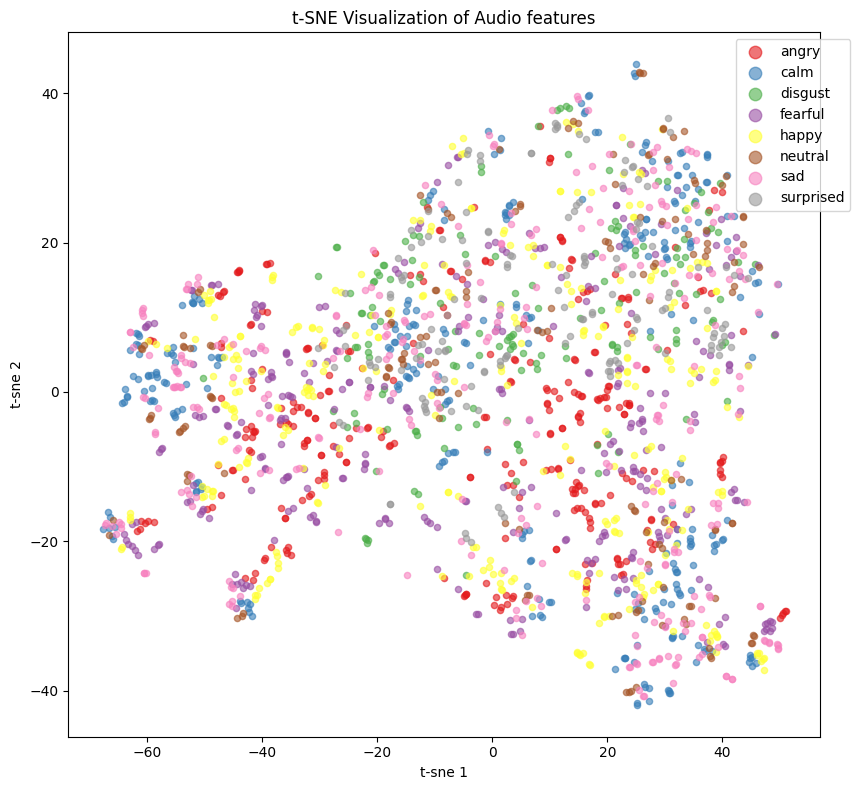

In [8]:
#tSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train)

plt.figure(figsize=(10,8))
emotions = np.unique(y_train)
colors = plt.cm.Set1(np.linspace(0,1,8))

for idx, emotion in enumerate(emotions):
    mask = y_train == emotion
    plt.scatter(X_tsne[mask,0], X_tsne[mask,1], c=[colors[idx]], label=emotion, alpha=0.6, s=20)

plt.title('t-SNE Visualization of Audio features')
plt.xlabel('t-sne 1')
plt.ylabel('t-sne 2')
plt.legend(markerscale=2, bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()
